In [274]:
import numpy as np
import pingouin as pg



In [275]:
np.random.seed(123)
mean, cov, n = [4, 5], [(1, .6), (.6, 1)], 30
x, y = np.random.multivariate_normal(mean, cov, n).T

# T-test
pg.ttest(x, y)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-3.400706,58,two-sided,0.001222,"[-1.68, -0.43]",0.878059,26.155,0.916807


/home/chris/Documents/code/NeuralABC_tools/.venv/lib/python3.12/site-packages/pingouin/plotting.py:573: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["wthn"] = data[within].replace({_ordr: i for i, _ordr in enumerate(order)})


Text(0.5, 1.0, 'Effect of meditation on school performance')

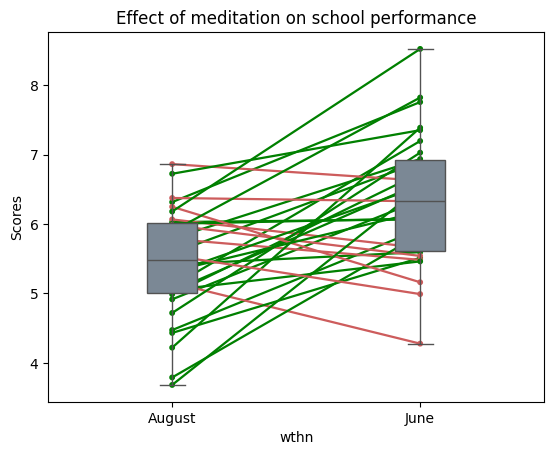

In [276]:
df = pg.read_dataset('mixed_anova').query("Group == 'Meditation' and Time != 'January'")
ax = pg.plot_paired(data=df, dv='Scores', within='Time', subject='Subject')
ax.set_title("Effect of meditation on school performance")

In [277]:
from pingouin import mediation_analysis, read_dataset
df = read_dataset('mediation')
mediation_analysis(data=df, x='X', m='M', y='Y', alpha=0.05,seed=42,n_boot=1000)

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,M ~ X,0.561015,0.094480,4.391362e-08,0.373522,0.748509,Yes
1,Y ~ M,0.654173,0.085831,1.612674e-11,0.483844,0.824501,Yes
2,Total,0.396126,0.111160,5.671128e-04,0.175533,0.616719,Yes
3,Direct,0.039604,0.109648,7.187429e-01,-0.178018,0.257226,No
4,Indirect,0.356522,0.083984,0.000000e+00,0.218835,0.538517,Yes


In [278]:
# add bootstrap samples
df = read_dataset('mediation')
print(len(df))
mediation_analysis(data=df, x='X', m='M', y='Y', alpha=0.05,seed=42,n_boot=5000)

100


,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,M ~ X,0.561015,0.094480,4.391362e-08,0.373522,0.748509,Yes
1,Y ~ M,0.654173,0.085831,1.612674e-11,0.483844,0.824501,Yes
2,Total,0.396126,0.111160,5.671128e-04,0.175533,0.616719,Yes
3,Direct,0.039604,0.109648,7.187429e-01,-0.178018,0.257226,No
4,Indirect,0.356522,0.079928,0.000000e+00,0.219475,0.536013,Yes


In [279]:
# add covariates
mediation_analysis(data=df, x='X', m='M', y='Y',
                   covar=['Mbin', 'Ybin'], seed=42).round(3)

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,M ~ X,0.559,0.097,0.000,0.367,0.752,Yes
1,Y ~ M,0.666,0.086,0.000,0.495,0.837,Yes
2,Total,0.420,0.113,0.000,0.196,0.645,Yes
3,Direct,0.064,0.110,0.561,-0.155,0.284,No
4,Indirect,0.356,0.086,0.000,0.209,0.553,Yes


In [280]:
df.describe()

,X,M,Y,Mbin,Ybin,W1,W2
count,100.000000,100.000000,100.000000,100.00,100.000000,100.000000,100.000000
mean,5.990000,4.860000,5.230000,0.45,0.530000,1.435000,0.970000
std,1.743646,1.901727,2.039286,0.50,0.501614,0.872721,0.064354
min,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.800000
25%,5.000000,3.000000,4.000000,0.00,0.000000,0.737500,1.000000
50%,6.000000,5.000000,5.000000,0.00,1.000000,1.400000,1.000000
75%,7.000000,6.000000,7.000000,1.00,1.000000,2.162500,1.000000
max,10.000000,10.000000,10.000000,1.00,1.000000,3.000000,1.000000


In [281]:
from scipy.stats import zscore
df_z = df.apply(zscore)
df_z.describe()

,X,M,Y,Mbin,Ybin,W1,W2
count,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02
mean,-1.521006e-16,-1.759703e-16,-1.940115e-16,-1.776357e-17,2.220446e-18,-5.551115e-17,5.051515e-16
std,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00
min,-3.452636e+00,-2.568446e+00,-2.577543e+00,-9.045340e-01,-1.061913e+00,-1.652567e+00,-2.654954e+00
25%,-5.706360e-01,-9.829856e-01,-6.061909e-01,-9.045340e-01,-1.061913e+00,-8.032511e-01,4.685213e-01
50%,5.764000e-03,7.398817e-02,-1.133528e-01,-9.045340e-01,9.416966e-01,-4.030651e-02,4.685213e-01
75%,5.821640e-01,6.024751e-01,8.723235e-01,1.105542e+00,9.416966e-01,8.377996e-01,4.685213e-01
max,2.311364e+00,2.716423e+00,2.350838e+00,1.105542e+00,9.416966e-01,1.802277e+00,4.685213e-01


In [282]:
mediation_analysis(data=df_z, x='X', m='M', y='Y',
                   covar=['Mbin', 'Ybin'], seed=42).round(3)

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,M ~ X,0.513,0.089,0.000,0.337,0.689,Yes
1,Y ~ M,0.621,0.080,0.000,0.462,0.780,Yes
2,Total,0.359,0.097,0.000,0.168,0.551,Yes
3,Direct,0.055,0.094,0.561,-0.132,0.243,No
4,Indirect,0.304,0.074,0.000,0.179,0.473,Yes


# Setup for voxel-based mediation analysis in stroke 

In [283]:
import nibabel as nb
import pandas as pd
import glob
from pathlib import Path
from matplotlib import pyplot as plt
import time



In [284]:
local_extras_dir = '../local_extras/'
#image_path = f'{local_extras_dir}/standardized_disconnectomes/' #pre-standardized
image_path = f'{local_extras_dir}/Structural-Proprioceptive-Disconnectome-Stroke-main/Disconnectomes/standardized_disconnectomes/'
mask_fname = f'{local_extras_dir}/disconnectome_38sub_WM_mask_no_cerebellum.nii.gz'
bx_df_fname = f'{local_extras_dir}/Demographics_and_Behavioural_Data.csv'



In [285]:
all_images = sorted(glob.glob(f'{image_path}/*.nii.gz'))
df = pd.read_csv(bx_df_fname)
mask = nb.load(mask_fname)
mask_d = mask.get_fdata()>0 #convert t binary

print(f'{len(all_images)} images found')
print(f'{(mask.get_fdata()>0).sum()} voxels in mask')
print(f'df shape: {df.shape}')
df.head()

0 images found
672377 voxels in mask
df shape: (39, 6)


,Subject,Sex (M=0),Age (y),FM-UL Score,APM Task Score,VGR Task Score
0,S01,0,79,17.0,3.29,2.82
1,S02,0,50,4.0,5.14,NaN
2,S03,0,68,45.0,1.09,0.94
3,S04,1,49,53.0,2.04,2.48
4,S05,1,50,51.0,2.12,3.52


In [286]:
all_images

[]

In [287]:
image_ids = [Path(f).stem.split('.')[0].split('_')[-1] for f in all_images]
print(len(image_ids))
df_subset = df[df['Subject'].isin(image_ids)].copy() #select the ones we have images for
#double-check that we have the same ID order for the data
assert(df_subset.Subject.tolist() == image_ids)

0


In [288]:
for idx,img_f in enumerate(all_images):
    print(idx,end=',')
    img = nb.load(img_f)
    if idx == 0:
        all_data = np.zeros((len(all_images), mask_d.sum()),dtype=np.float32)
    all_data[idx,:] = img.get_fdata()[mask_d]


Subjects X voxels
(38, 352110)
[ 3.1370866e-09 -1.5685433e-08 -6.2741732e-09 ... -1.9214655e-08
 -6.2741732e-09  1.0979803e-08]


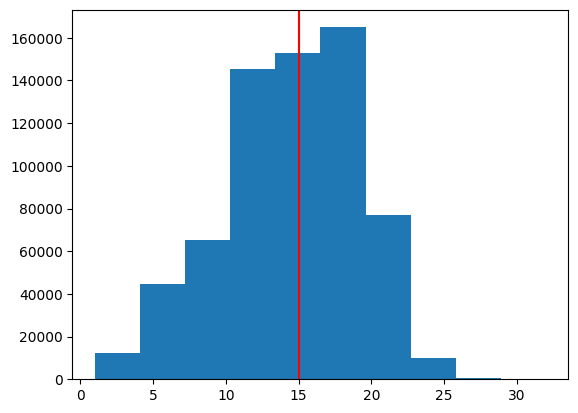

In [289]:
# subselect the data based on some thresholding
#check all_data for locations where there is no disconnectome

vox_pct_thresh = .01 #amount of disconnection to cut at
min_num_Ss= 15 #require this minimum number of subjects
Ss_w_vox_gt_thresh = (all_data>vox_pct_thresh).sum(axis=0)
_ = plt.hist(Ss_w_vox_gt_thresh,bins=10)
plt.axvline(min_num_Ss,color='r')
selected_vox_bool = Ss_w_vox_gt_thresh>=min_num_Ss


d_subset = all_data[:,selected_vox_bool]
d_subset_zscored = (d_subset - d_subset.mean(axis=0)) / d_subset.std(axis=0)
print("Subjects X voxels")
print(d_subset.shape)
print(np.mean(d_subset,axis=0))

In [290]:
# # appx 30-40k / hr
# # parallelized appx 17k in 5 mins
# _df = df_subset.copy()
# vox_idx = 0
# st = time.time()
# for vox_idx in range(all_data.shape[1]):
#     if np.mod(vox_idx,10000)==0:
#         print(vox_idx,end=',')
#     _df['vox_dconn_z'] = all_data[:,vox_idx]
    
#     res = mediation_analysis(data=_df, x='vox_dconn_z', m='APM Task Score', y='VGR Task Score',
#                     covar=['Age (y)', 'Sex (M=0)'], seed=42).to_numpy()
    
#     if vox_idx == 0:
#         row_names = [r[0] for r in res]
#         M_X = np.zeros((all_data.shape[1],6),dtype=np.float16)
#         Y_M = np.zeros_like(M_X)
#         tot = np.zeros_like(M_X)
#         direct = np.zeros_like(M_X)
#         indirect = np.zeros_like(M_X)

#     for r in res:
#         _d = r[1:]
#         if _d[-1] == 'Yes': #convert significance to binary
#             _d[-1] = 1
#         else:
#             _d[-1] = 0
#         if r[0] == 'APM Task Score ~ X':
#             M_X[vox_idx,:] = _d
#         elif r[0] == 'Y ~ APM Task Score':
#             Y_M[vox_idx,:] = _d
#         elif r[0] == 'Total':
#             tot[vox_idx,:] = _d
#         elif r[0] == 'Direct':
#             direct[vox_idx,:] = _d
#         elif r[0] == 'Indirect':
#             indirect[vox_idx,:] = _d

# et = time.time()
# print(f'\nTime elapsed: {et-st:.1f} seconds')
# print(f'\nTime elapsed: {(et-st)/60:.1f} minutes')


In [291]:
%timeit mediation_analysis(data=_df, x='vox_dconn_z', m='APM Task Score', y='VGR Task Score',covar=['Age (y)', 'Sex (M=0)'], seed=42)
%timeit mediation_analysis(data=_df, x='vox_dconn_z', m='APM Task Score', y='VGR Task Score',covar=['Age (y)', 'Sex (M=0)'], seed=42, n_boot=5000)

KeyboardInterrupt: 

In [ ]:
#setup the data structures for running the analysis

vox_idx = 0
_df = df_subset.copy()
_df['vox_dconn_z'] = d_subset_zscored[:,vox_idx]

# zscore the numeric columns
_df = _df.apply(lambda x: zscore(x) if x.name not in ['Subject'] else x)

res = mediation_analysis(data=_df, x='vox_dconn_z', m='APM Task Score', y='VGR Task Score',
                covar=['Age (y)', 'Sex (M=0)'], seed=42)

#column and rownames, so that we know what the outputs were
column_names = res.columns
row_names = res[column_names[0]].to_list()

n_vox = d_subset_zscored.shape[1]
print(_df.describe())
_df.head()

          Sex (M=0)       Age (y)   FM-UL Score  APM Task Score  \
count  3.800000e+01  3.800000e+01  3.800000e+01    3.800000e+01   
mean   2.337312e-17  1.110223e-16  6.135443e-17   -2.921640e-17   
std    1.013423e+00  1.013423e+00  1.013423e+00    1.013423e+00   
min   -7.211103e-01 -2.348124e+00 -2.492071e+00   -1.449403e+00   
25%   -7.211103e-01 -5.551671e-01 -3.416721e-01   -7.700575e-01   
50%   -7.211103e-01 -1.593195e-01  3.886521e-01   -1.326468e-01   
75%    1.386750e+00  7.255163e-01  7.335274e-01    5.404087e-01   
max    1.386750e+00  1.936344e+00  9.972556e-01    3.062794e+00   

       VGR Task Score   vox_dconn_z  
count    3.800000e+01  3.800000e+01  
mean     1.754810e-16  3.137087e-09  
std      1.013423e+00  1.013423e+00  
min     -1.646063e+00 -8.260882e-01  
25%     -9.080877e-01 -8.260882e-01  
50%      1.194723e-01 -3.779772e-01  
75%      7.546912e-01  5.200523e-01  
max      2.015788e+00  1.863920e+00  


,Subject,Sex (M=0),Age (y),FM-UL Score,APM Task Score,VGR Task Score,vox_dconn_z
0,S01,-0.72111,1.750063,-2.492071,1.301527,0.110131,1.415573
2,S03,-0.72111,0.725516,-0.219951,-0.543609,-1.646063,-0.826088
3,S04,1.38675,-1.044155,0.429226,0.253154,-0.207479,0.071623
4,S05,1.38675,-0.951015,0.266931,0.320250,0.764033,-0.826088
5,S07,-0.72111,-0.392171,0.185784,-0.543609,0.595886,-0.826088


In [ ]:
import numpy as np
from joblib import Parallel, delayed



def run_single_voxel(vox_idx,n_boot=10): #set n_boot to 50 for speed (5000 for real)
    X = d_subset_zscored[:, vox_idx]

    # Construct minimal DataFrame for each voxel/worker
    df = _df.copy()
    df['vox_dconn_z'] = X

    res = mediation_analysis(
        data=df,
        x='vox_dconn_z',
        m='APM Task Score',
        y='VGR Task Score',
        covar=['Age (y)', 'Sex (M=0)'],
        seed=42,
        n_boot=n_boot,
    ).to_numpy()

    # Output buffers (float32 faster & safer than float16)
    M_X = np.zeros(6, dtype=np.float32)
    Y_M = np.zeros(6, dtype=np.float32)
    tot = np.zeros(6, dtype=np.float32)
    direct = np.zeros(6, dtype=np.float32)
    indirect = np.zeros(6, dtype=np.float32)

    for name, *vals in res:
        vals[-1] = 1.0 if vals[-1] == 'Yes' else 0.0

        if name == 'APM Task Score ~ X':
            M_X[:] = vals
        elif name == 'Y ~ APM Task Score':
            Y_M[:] = vals
        elif name == 'Total':
            tot[:] = vals
        elif name == 'Direct':
            direct[:] = vals
        elif name == 'Indirect':
            indirect[:] = vals

    return M_X, Y_M, tot, direct, indirect


In [ ]:
results = Parallel(
    n_jobs=-1,          # use all cores
    backend='loky',
    verbose=5
)(
    delayed(run_single_voxel)(i,n_boot=10) for i in range(n_vox)
)

M_X = np.vstack([r[0] for r in results])
Y_M = np.vstack([r[1] for r in results])
tot = np.vstack([r[2] for r in results])
direct = np.vstack([r[3] for r in results])
indirect = np.vstack([r[4] for r in results])



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done 133 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 576 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done 1224 tasks      | elapsed:    8.1s
[Parallel(n_jobs=-1)]: Done 2016 tasks      | elapsed:   10.1s
[Parallel(n_jobs=-1)]: Done 2952 tasks      | elapsed:   12.7s
[Parallel(n_jobs=-1)]: Done 4032 tasks      | elapsed:   15.7s
[Parallel(n_jobs=-1)]: Done 5256 tasks      | elapsed:   19.0s
[Parallel(n_jobs=-1)]: Done 6624 tasks      | elapsed:   22.8s
[Parallel(n_jobs=-1)]: Done 8136 tasks      | elapsed:   26.5s
[Parallel(n_jobs=-1)]: Done 9792 tasks      | elapsed:   30.9s
[Parallel(n_jobs=-1)]: Done 11592 tasks      | elapsed:   35.5s
[Parallel(n_jobs=-1)]: Done 13536 tasks      | elapsed:   40.5s


In [ ]:
%timeit mediation_analysis(data=_df, x='vox_dconn_z', m='APM Task Score', y='VGR Task Score',covar=['Age (y)', 'Sex (M=0)'], seed=42).to_numpy()

112 ms ± 6.22 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [293]:
%timeit run_single_voxel(0,n_boot=10)

11.3 ms ± 101 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
st = time.time()
_r = run_single_voxel(0,n_boot=5)
print(time.time()-st)
st = time.time()
_r2 = run_single_voxel(0,n_boot=5000)
print(time.time()-st)



0.017385005950927734
1.1070659160614014


(array([0.45423442, 0.14397542, 0.00335115, 0.16164117, 0.7468277 ,
        1.        ], dtype=float32),
 array([0.49647132, 0.16119266, 0.00408123, 0.16888842, 0.8240542 ,
        1.        ], dtype=float32),
 array([ 0.20405684,  0.17045216,  0.23952845, -0.14234364,  0.55045736,
         0.        ], dtype=float32),
 array([-0.02773931,  0.17750524,  0.8767698 , -0.38887644,  0.3333978 ,
         0.        ], dtype=float32),
 array([0.23179616, 0.19184901, 0.        , 0.26243585, 0.26243585,
        1.        ], dtype=float32))

In [ ]:
res2 = run_single_voxel(0)
vox_idx = 0
_df['vox_dconn_z'] = all_data[:,vox_idx]
res = mediation_analysis(data=_df, x='vox_dconn_z', m='APM Task Score', y='VGR Task Score',covar=['Age (y)', 'Sex (M=0)'], seed=42).to_numpy()


In [ ]:
for idx,rr in enumerate(res):
    print(f'{rr[2]} {res2[idx][1]}')


0.17166532520794564 0.17166532576084137
0.1447226506999749 0.14472265541553497
0.1824685483196152 0.18246854841709137
0.19001883767958302 0.19001883268356323
0.17033459063854972 0.170334592461586
